# GP-5: Deep Learning
## Анализ аренды квартир в Москве на платформе Циан
Выполнили: Суворов Александр, Белоусов Дмитрий, Морозова Мария.  ББИ233

В данном ноутбуке мы будем обрабатывать собранные парсингом + api данные объявлений аренды квартир с платформы Циан. Мы предобработанные данные, проведем eda, фиче инжениринг, в общем подготовим таблицу объявлений к задаче определения цены квартиры.

In [ ]:
!pip install torchinfo

In [ ]:
import os
import wandb

import numpy as np
import pandas as pd
pd.set_option("display.max_columns", None)
import seaborn as sns

import random
from tqdm import *
import matplotlib.pyplot as plt
%matplotlib inline

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets
import torchvision.transforms as transforms
from torchinfo import summary

from PIL import Image
import kagglehub
from pathlib import Path
import json
import ast


In [ ]:
path = kagglehub.dataset_download("beldmian/moscow-rent-cian-with-images")

print("Path to dataset files:", path)

100%|██████████| 7.26G/7.26G [01:29<00:00, 86.9MB/s]


Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/beldmian/moscow-rent-cian-with-images/versions/4


In [ ]:
root = Path(path)

print("Root:", root)
print("\nFiles and folders in root:")

for item in root.iterdir():
    size_mb = item.stat().st_size / 1024 / 1024
    print("[FILE]", item.name, f"{size_mb:.2f} MB")

Root: /root/.cache/kagglehub/datasets/beldmian/moscow-rent-cian-with-images/versions/4

Files and folders in root:
[FILE] images_512_q60.tar.zst 7419.69 MB
[FILE] moscow_rent_all.csv 107.23 MB
[FILE] image_manifest.csv 77.58 MB
[FILE] README.md 0.01 MB


In [ ]:
rent_df = pd.read_csv(root / "moscow_rent_all.csv", sep=';')
images_df = pd.read_csv(root / "image_manifest.csv", sep=';')

rent_df.shape, images_df.shape

/tmp/ipykernel_2026/3617380898.py:1: DtypeWarning: Columns (25) have mixed types. Specify dtype option on import or set low_memory=False.
  rent_df = pd.read_csv(root / "moscow_rent_all.csv", sep=';')


((24055, 43), (410107, 1))

In [ ]:
rent_df.sample(5)

,offer_id,deal_type,url,title,price_rub,price_formatted,rooms,area_sqm,floor,floors_total,address,district,metro,metro_time_min,author,author_type,residential_complex,added,description,repair,repair_type,ceiling_height_m,build_year,house_material,heating_type,parking_type,kitchen_area_sqm,living_area_sqm,deposit_rub,prepay_months,utilities_included,loggias_count,balconies_count,combined_wcs_count,separate_wcs_count,pets_allowed,children_allowed,passenger_lifts_count,detail_features,details_fetched,image_urls,image_paths,images_count
4600,267554175,rent,https://www.cian.ru/rent/flat/267554175/?mlSea...,NaN,65000,65 000 ₽/мес.,1.0,33.0,9,9,"Россия, Москва, улица Цюрупы, 18к2",р-н Черемушки,Новые Черёмушки,16.0,Александра Ивашкевич,agent,NaN,"18 май, 13:55",Отличный вариант однокомнатной квартиры студий...,Косметический,cosmetic,NaN,1961.0,Блочный,NaN,NaN,6.0,20.0,62000.0,1.0,True,NaN,NaN,1.0,NaN,NaN,NaN,NaN,"{""Тип дома"": ""Блочный"", ""Год постройки"": ""1961...",True,https://images.cdn-cian.ru/images/45/970/911/k...,images/rent/267554175/01.jpg|images/rent/26755...,10
2149,205624408,rent,https://www.cian.ru/rent/flat/205624408/?mlSea...,NaN,49000,49 000 ₽/мес.,1.0,38.0,17,17,"Россия, Москва, Московский, улица Лаптева, 8к1",Московский,Филатов Луг,10.0,10188466,NaN,Город-парк Первый Московский,"26 май, 17:35","Я собственник. \nС 15 июня возможны просмотры,...",Косметический,cosmetic,NaN,2017.0,Панельный,NaN,NaN,9.0,17.0,40000.0,1.0,True,NaN,1.0,1.0,NaN,NaN,True,NaN,"{""Тип дома"": ""Панельный"", ""Год постройки"": ""20...",True,https://images.cdn-cian.ru/images/6/953/376/kv...,images/rent/205624408/01.jpg|images/rent/20562...,12
18696,329702705,rent,https://www.cian.ru/rent/flat/329702705/?mlSea...,Вид на сад Эрмитаж,200000,200 000 ₽/мес.,3.0,84.0,7,13,"Россия, Москва, улица Малая Дмитровка, 24/2",р-н Тверской,Маяковская,9.0,Юлия Дмитриева,agent,NaN,"4 июн, 16:19",ID 11747: На М.Дмитровке 24/2 в кирпичном до...,Евроремонт,euro,NaN,1993.0,Кирпичный,NaN,NaN,15.0,50.0,200000.0,1.0,True,NaN,1.0,1.0,NaN,True,True,NaN,"{""Тип дома"": ""Кирпичный"", ""Год постройки"": ""19...",True,https://images.cdn-cian.ru/images/kvartira-mos...,images/rent/329702705/01.jpg|images/rent/32970...,13
8218,330140701,rent,https://www.cian.ru/rent/flat/330140701/?mlSea...,NaN,50000,50 000 ₽/мес.,2.0,38.6,7,12,"Россия, Москва, Туристская улица, 31к1",р-н Северное Тушино,Планерная,17.0,407918,NaN,NaN,"8 июн, 16:23",Квартира в ухоженном доме.\nХорошее состояние ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,{},False,https://images.cdn-cian.ru/images/kvartira-mos...,images/rent/330140701/01.jpg|images/rent/33014...,23
7138,330812471,rent,https://www.cian.ru/rent/flat/330812471/?mlSea...,NaN,118000,118 000 ₽/мес.,1.0,36.0,5,14,"Россия, Москва, Очаковское шоссе, 9А",р-н Очаково-Матвеевское,Аминьевская,4.0,NaN,agent,Вангарден,"5 июн, 16:59","Евро двухкомнатная квартира в ЖК Вангарден, кл...",Дизайнерский,design,NaN,2023.0,NaN,NaN,NaN,NaN,NaN,0.0,1.0,True,NaN,NaN,1.0,NaN,NaN,NaN,NaN,"{""Год постройки"": ""2023"", ""Ремонт"": ""Дизайнерс...",True,https://images.cdn-cian.ru/images/kvartira-mos...,images/rent/330812471/01.jpg|images/rent/33081...,12


In [ ]:
rent_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24055 entries, 0 to 24054
Data columns (total 43 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   offer_id               24055 non-null  int64  
 1   deal_type              24055 non-null  object 
 2   url                    24055 non-null  object 
 3   title                  1027 non-null   object 
 4   price_rub              24055 non-null  int64  
 5   price_formatted        24055 non-null  object 
 6   rooms                  20973 non-null  float64
 7   area_sqm               24055 non-null  float64
 8   floor                  24055 non-null  int64  
 9   floors_total           24055 non-null  int64  
 10  address                24055 non-null  object 
 11  district               24055 non-null  object 
 12  metro                  23987 non-null  object 
 13  metro_time_min         23987 non-null  float64
 14  author                 20880 non-null  object 
 15  au

In [ ]:
rent_df.duplicated().sum()

np.int64(0)

Дубликатов нет, так же для удобства давайте удалим все ненужные признаки из датасета, например ссылки, автора и тд

In [ ]:
rent_df.drop(columns=['url', 'image_urls', 'image_paths', 'author', 'repair'], inplace=True)
rent_df.sample(5)

,offer_id,deal_type,title,price_rub,price_formatted,rooms,area_sqm,floor,floors_total,address,district,metro,metro_time_min,author_type,residential_complex,added,description,repair_type,ceiling_height_m,build_year,house_material,heating_type,parking_type,kitchen_area_sqm,living_area_sqm,deposit_rub,prepay_months,utilities_included,loggias_count,balconies_count,combined_wcs_count,separate_wcs_count,pets_allowed,children_allowed,passenger_lifts_count,detail_features,details_fetched,images_count
14120,329924186,rent,NaN,119000,119 000 ₽/мес.,2.0,40.0,13,21,"Россия, Москва, Большая Спасская улица, 35",р-н Красносельский,Площадь трёх вокзалов,4.0,agent,Dialog,"4 июн, 18:52",Kвapтиpa в ЖK Диaлог отвечаeт самым выcoким т...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,{},False,17
6544,322735319,rent,NaN,87000,87 000 ₽/мес.,1.0,32.2,25,33,"Россия, Москва, проезд Стройкомбината, 1",р-н Очаково-Матвеевское,Очаково,6.0,NaN,Новое Очаково,"4 июн, 11:41",Сдается на длительный срок уютная новая кварти...,design,NaN,2024.0,NaN,NaN,NaN,4.0,16.0,87000.0,1.0,True,NaN,NaN,1.0,NaN,NaN,NaN,NaN,"{""Год постройки"": ""2024"", ""Жилая площадь"": ""16...",True,30
8706,265431780,rent,NaN,48000,48 000 ₽/мес.,2.0,45.0,4,9,"Россия, Москва, Домодедовская улица, 1к1",р-н Орехово-Борисово Северное,Орехово,14.0,NaN,NaN,"30 май, 15:34","Дом после капитального ремонта, квартира с из...",cosmetic,NaN,1973.0,Панельный,NaN,NaN,7.0,32.0,48000.0,1.0,True,NaN,NaN,NaN,1.0,NaN,NaN,NaN,"{""Тип дома"": ""Панельный"", ""Год постройки"": ""19...",True,13
10029,330831200,rent,NaN,70000,70 000 ₽/мес.,2.0,60.5,16,17,"Россия, Москва, поселение Внуковское, улица Бо...",Внуковское,Рассказовка,3.0,NaN,Город-парк Переделкино Ближнее,"7 июн, 13:25",Сдаётся уютная 2-комнатная квартира в современ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,{},False,16
13730,329176516,rent,NaN,120000,120 000 ₽/мес.,2.0,55.0,5,5,"Россия, Москва, улица Большая Ордынка, 17с1",р-н Замоскворечье,Третьяковская,3.0,agent,NaN,"20 май, 15:19",ПРЯМОЙ ПРЕДСТАВИТЕЛЬ СОБСТВЕННИКА! В аренду пр...,cosmetic,NaN,1900.0,Блочный,NaN,NaN,10.0,NaN,120000.0,1.0,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{""Тип дома"": ""Блочный"", ""Год постройки"": ""1900...",True,14


В целом уже помно начинать eda, но давайте еще предобработаем столбец `detail_features`, так как он очень интересный, но пока представлен просто в формате json.

In [ ]:
def parse_detail_features(value):
    if pd.isna(value):
        return {}

    try:
        return json.loads(value)
    except:
        return {}

In [ ]:
detail_features_parsed = rent_df["detail_features"].apply(parse_detail_features)
detail_features_parsed

,detail_features
0,"{'Тип дома': 'Кирпичный', 'Год постройки': '19..."
1,"{'Тип дома': 'Панельный', 'Год постройки': '20..."
2,"{'Год постройки': '2022', 'Жилая площадь': '25..."
3,"{'Тип дома': 'Кирпичный', 'Год постройки': '19..."
4,"{'Жилая площадь': '14 м²', 'Кухня': '8 м²', 'Р..."
...,...
24050,"{'Год постройки': '2024', 'Кухня': '8 м²', 'Ре..."
24051,"{'Тип дома': 'Кирпичный', 'Год постройки': '20..."
24052,"{'Тип дома': 'Монолитный', 'Год постройки': '2..."
24053,"{'Тип дома': 'Монолитный', 'Год постройки': '2..."


In [ ]:
detail_features_df = pd.json_normalize(detail_features_parsed)
detail_features_df.sample(5)

,Тип дома,Год постройки,Ремонт,Санузел,В квартире есть,Оплата ЖКХ,Залог,Комиссия,Предоплата,Срок аренды,Условия проживания,Жилая площадь,Кухня,Площадь кухни,Балкон,Комиссии,Высота потолков,Парковка,Лоджии,Балконы,Можно с животными,Можно с детьми,Вид из окон,Залога
14475,Монолитный,2020,Дизайнерский,1 совмещенный,"Мебель в комнатах, интернет, мебель на кухне, ...",Включена (без счётчиков),160 000 ₽,50%,1 месяц,От года,Можно c детьми и животными,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11232,Кирпичный,1961,Евроремонт,1 раздельный,"Мебель в комнатах, интернет, мебель на кухне, ...",Включена (без счётчиков),85 000 ₽,50%,1 месяц,От года,NaN,28 м²,7 м²,7 м²,1 балкон,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
21556,NaN,NaN,Евроремонт,1 совмещенный,"Мебель в комнатах, мебель на кухне, стиральная...",Включена (счётчики включены),45 000 ₽,NaN,1 месяц,Несколько месяцев,NaN,19 м²,NaN,NaN,NaN,Нет,NaN,NaN,NaN,NaN,NaN,NaN,Во двор,NaN
20901,NaN,1913,Дизайнерский,"1 совмещенный, 1 раздельный","Мебель в комнатах, мебель на кухне, телевизор,...",Включена (без счётчиков),"1,8 млн ₽",NaN,1 месяц,От года,Можно c детьми и животными,NaN,NaN,NaN,1 балкон,Нет,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3615,Монолитный,2020,Евроремонт,1 совмещенный,"Мебель в комнатах, интернет, мебель на кухне, ...",Включена (счётчики включены),59 000 ₽,50%,1 месяц,От года,NaN,NaN,15 м²,15 м²,1 лоджия,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Здесь мы видим, что большинство признаков уже есть в основной таблице, давайте возьмем только новые:
[
    "В квартире есть",
    "Комиссия",
    "Срок аренды",
    "Условия проживания",
    "Вид из окон"
]
И сделаем новые признаки, и потом добавим к основной таблице

In [ ]:
selected_features = [
    "В квартире есть",
    "Комиссия",
    "Срок аренды",
    "Вид из окон"
]

features_df = detail_features_df[selected_features].copy()

features_df.sample(5)

,В квартире есть,Комиссия,Срок аренды,Вид из окон
12690,"Мебель в комнатах, интернет, мебель на кухне, ...",50%,От года,Во двор
9030,"Мебель в комнатах, интернет, мебель на кухне, ...",NaN,Несколько месяцев,На улицу
14443,"Мебель в комнатах, интернет, мебель на кухне, ...",NaN,От года,Во двор
5154,"Мебель в комнатах, интернет, мебель на кухне, ...",70%,От года,NaN
13166,NaN,NaN,NaN,NaN


In [ ]:
features_df['Комиссия'].unique()

array(['100%', '70%', nan, '60%', '80%', '40%', '50%', '30%', '85%',
       '65%', '90%', '55%', '75%', '20%', '25%', '35%', '15%', '45%',
       '9%', '69%', '67%', '72%', '93%', '28%', '95%', '49%', '64%',
       '10%', '91%', '53%', '99%', '46%', '73%', '68%', '1%', '4%', '82%',
       '66%', '62%', '63%', '39%', '57%', '47%', '37%', '33%', '59%',
       '58%', '32%', '89%', '2%', '38%', '8%', '88%', '54%', '14%', '71%',
       '79%', '34%', '27%', '61%', '31%', '43%', '5%', '26%', '48%',
       '56%', '78%', '44%', '98%'], dtype=object)

In [ ]:
features_df['Срок аренды'].unique()

array(['От года', 'Несколько месяцев', nan], dtype=object)

In [ ]:
features_df['Вид из окон'].unique()

array([nan, 'Во двор', 'На улицу', 'На улицу и двор'], dtype=object)

In [ ]:
features_df['В квартире есть'].unique()[:10]

array(['Мебель в комнатах, интернет, мебель на кухне, телевизор, стиральная машина, кондиционер, посудомоечная машина, мусоропровод',
       'Мебель в комнатах, мебель на кухне, стиральная машина',
       'Мебель в комнатах, мебель на кухне, стиральная машина, мусоропровод',
       'Мебель в комнатах, интернет, мебель на кухне, телевизор, стиральная машина, мусоропровод',
       'Мусоропровод', nan,
       'Интернет, мебель на кухне, стиральная машина',
       'Мебель в комнатах, интернет, мебель на кухне, телевизор, стиральная машина',
       'Мебель в комнатах, интернет, мебель на кухне, стиральная машина',
       'Мебель в комнатах, интернет, мебель на кухне, мусоропровод'],
      dtype=object)

Тогда давайте обработаем `Комиссия` просто убрав процент, `Срок аренды` сделаем булевой переменной + nan, `Вид из окон` сделаем label encoding. А столбец В квартире есть - каждую строку приведем к нижнему регистру, сделаем словарь и далее one hot признаки.

In [ ]:
features_df = features_df.rename(columns={
    "В квартире есть": "flat_features",
    "Комиссия": "commission",
    "Срок аренды": "rent_period",
    "Вид из окон": "window_view"
})

features_df.sample(5)

,flat_features,commission,rent_period,window_view
6369,"Мебель в комнатах, интернет, мебель на кухне, ...",NaN,От года,NaN
6459,"Мебель в комнатах, интернет, мебель на кухне, ...",25%,От года,Во двор
15,"Мебель в комнатах, интернет, мебель на кухне, ...",70%,От года,Во двор
9281,"Мебель в комнатах, мебель на кухне, стиральная...",NaN,От года,Во двор
9677,"Мебель в комнатах, интернет, мебель на кухне, ...",NaN,От года,NaN


In [ ]:
features_df["commission"] = features_df["commission"].str.replace("%", "", regex=False).astype("float")

features_df["is_long_rent"] = features_df["rent_period"].map({"От года": True, "Несколько месяцев": False}).astype("boolean")
features_df.drop(columns=["rent_period"], inplace=True)

features_df

,flat_features,commission,window_view,is_long_rent
0,"Мебель в комнатах, интернет, мебель на кухне, ...",100.0,NaN,True
1,"Мебель в комнатах, мебель на кухне, стиральная...",70.0,NaN,True
2,"Мебель в комнатах, мебель на кухне, стиральная...",NaN,NaN,True
3,"Мебель в комнатах, интернет, мебель на кухне, ...",70.0,NaN,True
4,Мусоропровод,60.0,NaN,False
...,...,...,...,...
24050,"Мебель в комнатах, мебель на кухне, стиральная...",50.0,NaN,True
24051,"Мебель в комнатах, интернет, мебель на кухне, ...",NaN,На улицу и двор,True
24052,"Интернет, мебель на кухне, телевизор, стиральн...",NaN,На улицу,True
24053,"Мебель в комнатах, мебель на кухне, телевизор,...",NaN,NaN,True


In [ ]:
features_df["window_view"] = features_df["window_view"].map({"Во двор": 0, "На улицу": 1, "На улицу и двор": 2}).astype("float")
features_df.sample(5)

,flat_features,commission,window_view,is_long_rent
19675,"Мебель в комнатах, интернет, мебель на кухне, ...",NaN,2.0,True
4347,"Мебель в комнатах, интернет, мебель на кухне, ...",60.0,0.0,True
11666,"Мебель в комнатах, интернет, мебель на кухне, ...",65.0,NaN,True
13210,Телевизор,50.0,NaN,True
15557,"Мебель в комнатах, интернет, мебель на кухне, ...",NaN,1.0,True


In [ ]:
flat_features_clean = features_df["flat_features"].fillna("").str.lower().str.replace(r"\s*,\s*", ",", regex=True)
flat_features_ohe = flat_features_clean.str.get_dummies(sep=",").astype(bool)
flat_features_ohe.columns = ["has_" + col.replace(" ", "_") for col in flat_features_ohe.columns]

features_df = pd.concat([features_df.drop(columns=["flat_features"]), flat_features_ohe], axis=1)

In [ ]:
features_df

,commission,window_view,is_long_rent,has_интернет,has_кондиционер,has_мебель_в_комнатах,has_мебель_на_кухне,has_мусоропровод,has_посудомоечная_машина,has_стиральная_машина,has_телевизор
0,100.0,NaN,True,True,True,True,True,True,True,True,True
1,70.0,NaN,True,False,False,True,True,False,False,True,False
2,NaN,NaN,True,False,False,True,True,True,False,True,False
3,70.0,NaN,True,True,False,True,True,True,False,True,True
4,60.0,NaN,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
24050,50.0,NaN,True,False,True,True,True,False,True,True,False
24051,NaN,2.0,True,True,True,True,True,True,True,True,True
24052,NaN,1.0,True,True,False,False,True,True,False,True,True
24053,NaN,NaN,True,False,True,True,True,False,True,True,True


In [ ]:
features_df = features_df.rename(columns={
    "has_интернет": "has_internet",
    "has_кондиционер": "has_air_conditioner",
    "has_мебель_в_комнатах": "has_room_furniture",
    "has_мебель_на_кухне": "has_kitchen_furniture",
    "has_мусоропровод": "has_garbage_chute",
    "has_посудомоечная_машина": "has_dishwasher",
    "has_стиральная_машина": "has_washing_machine",
    "has_телевизор": "has_tv"
})

features_df

,commission,window_view,is_long_rent,has_internet,has_air_conditioner,has_room_furniture,has_kitchen_furniture,has_garbage_chute,has_dishwasher,has_washing_machine,has_tv
0,100.0,NaN,True,True,True,True,True,True,True,True,True
1,70.0,NaN,True,False,False,True,True,False,False,True,False
2,NaN,NaN,True,False,False,True,True,True,False,True,False
3,70.0,NaN,True,True,False,True,True,True,False,True,True
4,60.0,NaN,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
24050,50.0,NaN,True,False,True,True,True,False,True,True,False
24051,NaN,2.0,True,True,True,True,True,True,True,True,True
24052,NaN,1.0,True,True,False,False,True,True,False,True,True
24053,NaN,NaN,True,False,True,True,True,False,True,True,True


Ух, не просто было, но давайте теперь склеим все во едино! в главную таблицу `rent_df`!

In [ ]:
rent_df = pd.concat([rent_df, features_df], axis=1)
rent_df.sample(5)

,offer_id,deal_type,title,price_rub,price_formatted,rooms,area_sqm,floor,floors_total,address,district,metro,metro_time_min,author_type,residential_complex,added,description,repair_type,ceiling_height_m,build_year,house_material,heating_type,parking_type,kitchen_area_sqm,living_area_sqm,deposit_rub,prepay_months,utilities_included,loggias_count,balconies_count,combined_wcs_count,separate_wcs_count,pets_allowed,children_allowed,passenger_lifts_count,detail_features,details_fetched,images_count,commission,window_view,is_long_rent,has_internet,has_air_conditioner,has_room_furniture,has_kitchen_furniture,has_garbage_chute,has_dishwasher,has_washing_machine,has_tv
6262,294967079,rent,NaN,90000,90 000 ₽/мес.,1.0,43.0,25,25,"Россия, Москва, Аминьевское шоссе, 4Дк1",р-н Очаково-Матвеевское,Аминьевская,5.0,agent,NaN,"30 май, 20:45",New\nВидовая\nКлючи на руках\nБыстрый выход на...,design,NaN,2022.0,Блочный,NaN,NaN,NaN,NaN,90000.0,1.0,True,1.0,NaN,1.0,NaN,True,True,NaN,"{""Тип дома"": ""Блочный"", ""Год постройки"": ""2022...",True,24,60.0,2.0,True,True,True,True,True,False,True,True,True
15973,325327089,rent,Возможен торг!,330000,330 000 ₽/мес.,2.0,65.0,3,9,"Россия, Москва, 1-я Тверская-Ямская улица, 2А",р-н Тверской,Маяковская,2.0,agent,Веспер Тверская,"сегодня, 08:53",ЖК Vesper Тверская. К долгосрочной аренде пред...,design,NaN,NaN,NaN,NaN,NaN,24.0,NaN,330000.0,1.0,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{""Кухня"": ""24 м²"", ""Ремонт"": ""Дизайнерский"", ""...",True,18,NaN,2.0,True,False,False,True,False,False,False,False,False
22417,330931064,rent,NaN,60000,60 000 ₽/мес.,NaN,23.0,3,18,"Россия, Москва, Олонецкая улица, 6",р-н Останкинский,Ботанический сад,4.0,NaN,Грин парк,"вчера, 23:04",Впервые сдается уютная студия 23 м2 в ЖК Гринп...,design,NaN,2024.0,NaN,NaN,NaN,3.0,15.0,60000.0,1.0,True,NaN,NaN,1.0,NaN,NaN,NaN,NaN,"{""Год постройки"": ""2024"", ""Жилая площадь"": ""15...",True,21,NaN,2.0,True,True,True,True,True,False,False,True,True
22236,298093073,rent,NaN,58000,58 000 ₽/мес.,NaN,32.5,3,21,"Россия, Москва, Востряковское шоссе, 7с3",р-н Тропарево-Никулино,Озёрная,20.0,agent,МФК СИТИМИКС,"вчера, 23:20","СДАЕТСЯ СТУДИЯ В ЖК ""СИТИ МИКС"", с современны...",euro,NaN,2020.0,Монолитный,NaN,NaN,NaN,NaN,58000.0,1.0,True,NaN,NaN,1.0,NaN,NaN,NaN,NaN,"{""Тип дома"": ""Монолитный"", ""Год постройки"": ""2...",True,22,50.0,NaN,True,True,False,True,True,False,False,True,True
5721,311086613,rent,NaN,73000,73 000 ₽/мес.,1.0,41.1,20,24,"Россия, Москва, Ленинский проспект, 134",р-н Проспект Вернадского,Проспект Вернадского,16.0,agent,NaN,"8 июн, 17:27","Сдается уютная , светлая и просторная 1-комна...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,{},False,23,NaN,NaN,<NA>,False,False,False,False,False,False,False,False


In [ ]:
rent_df.drop(columns='detail_features', inplace=True)

In [ ]:
rent_df.drop(columns='price_formatted', inplace=True)

In [ ]:
rent_df.drop(columns='title', inplace=True)

Такс, у нас еще есть дата и время, но давайте для простоты просто уберем этот признак, так как мы далее его использовать не будем.

In [ ]:
rent_df.drop(columns='added', inplace=True)

Так как мы не будем работать с описанием квартир, то давайте просто также удалим признак `description`

In [ ]:
rent_df.drop(columns='description', inplace=True)

Так же давайте удалим признак `address`, он был бы нам полезен если бы мы сравнивали квартиры на одной улице (например среднее аренды) говорили завышена ли цена или нет. Но в данном случае просто для простоты уберем, как как информация о местности уже косвенно зашита в район, станцию метро, и время до метро!

In [ ]:
rent_df.drop(columns='address', inplace=True)

In [ ]:
rent_df.sample(5)

,offer_id,deal_type,price_rub,rooms,area_sqm,floor,floors_total,district,metro,metro_time_min,author_type,residential_complex,repair_type,ceiling_height_m,build_year,house_material,heating_type,parking_type,kitchen_area_sqm,living_area_sqm,deposit_rub,prepay_months,utilities_included,loggias_count,balconies_count,combined_wcs_count,separate_wcs_count,pets_allowed,children_allowed,passenger_lifts_count,details_fetched,images_count,commission,window_view,is_long_rent,has_internet,has_air_conditioner,has_room_furniture,has_kitchen_furniture,has_garbage_chute,has_dishwasher,has_washing_machine,has_tv
18757,329650770,rent,200000,3.0,80.0,3,12,р-н Лефортово,Площадь Ильича,7.0,agent,Символ,euro,NaN,2019.0,Монолитный,NaN,NaN,23.0,52.0,200000.0,NaN,True,NaN,1.0,1.0,1.0,True,True,NaN,True,24,NaN,0.0,True,True,True,True,True,True,True,True,True
492,330864073,rent,46000,1.0,36.0,2,14,р-н Вешняки,Новогиреево,17.0,agent,NaN,cosmetic,NaN,1972.0,Блочный,NaN,NaN,7.0,18.0,46000.0,1.0,True,1.0,NaN,1.0,NaN,NaN,True,NaN,True,17,50.0,NaN,True,False,False,True,True,True,False,True,False
5511,327707388,rent,75000,1.0,46.0,12,14,р-н Сокол,Сокол,10.0,agent,NaN,design,NaN,NaN,NaN,NaN,NaN,7.0,33.0,75000.0,1.0,True,NaN,NaN,1.0,NaN,NaN,NaN,NaN,True,26,60.0,NaN,True,True,True,True,True,False,False,True,True
3340,312075942,rent,55000,1.0,26.0,9,21,Сосенское,Коммунарка,16.0,NaN,Новая Звезда,euro,NaN,2016.0,Монолитно кирпичный,NaN,NaN,5.0,16.0,55000.0,1.0,True,NaN,NaN,1.0,NaN,NaN,NaN,NaN,True,31,NaN,2.0,True,False,False,True,True,False,False,True,True
6828,320189190,rent,100000,1.0,35.0,16,25,р-н Нижегородский,Нижегородская,12.0,NaN,Аквилон Beside,cosmetic,NaN,2024.0,NaN,NaN,NaN,NaN,NaN,100000.0,1.0,True,1.0,NaN,NaN,NaN,NaN,NaN,NaN,True,45,NaN,NaN,True,True,True,True,False,False,True,True,True


In [ ]:
df = rent_df.drop(columns=['offer_id', 'deal_type']) # убираем deal_type так как наш датасет исходно про аренду только
# уберем offer_id, но при этом сохраним датасет, он понадобиться для связи картинок

Давайте перед началом предобработки проанализируем имеющиеся данные, посмотрим на распределения.

In [ ]:
# здесь ручками пропишим наши признаки на 4 типа

numeric_cols = [
    "price_rub",
    "area_sqm",
    "floor",
    "floors_total",
    "metro_time_min",
    "ceiling_height_m",
    "build_year",
    "kitchen_area_sqm",
    "living_area_sqm",
    "deposit_rub",
    "loggias_count",
    "balconies_count",
    "combined_wcs_count",
    "separate_wcs_count",
    "passenger_lifts_count",
    "images_count",
    "rooms",
    "prepay_months",
    "commission",
    "window_view"
]

bool_cols = [
    "details_fetched",
    "is_long_rent",
    "has_internet",
    "has_air_conditioner",
    "has_room_furniture",
    "has_kitchen_furniture",
    "has_garbage_chute",
    "has_dishwasher",
    "has_washing_machine",
    "has_tv",
    "utilities_included",
    "pets_allowed",
    "children_allowed"
]

categorical_cols = [
    "district",
    "metro",
    "author_type",
    "residential_complex",
    "repair_type",
    "house_material",
    "parking_type"
]

### Давайте посмотрим на числовые признаки

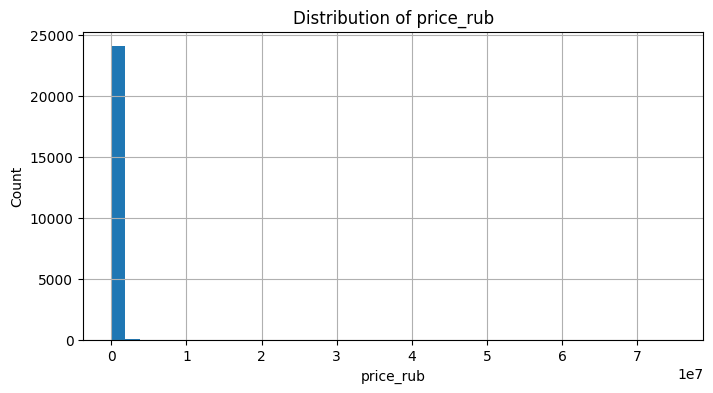

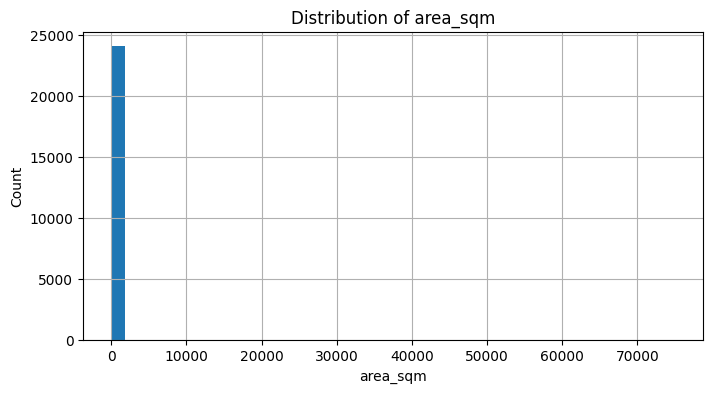

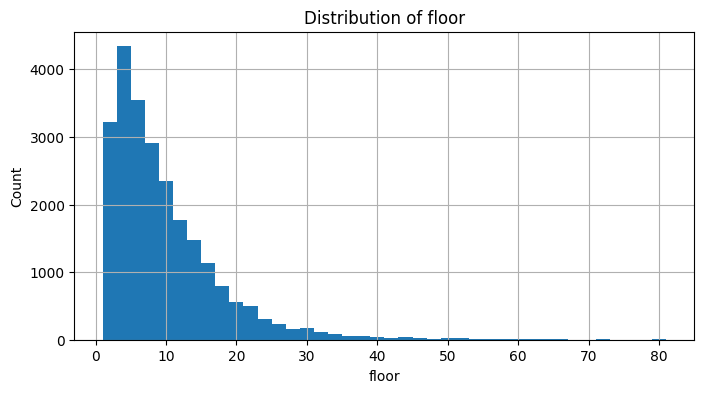

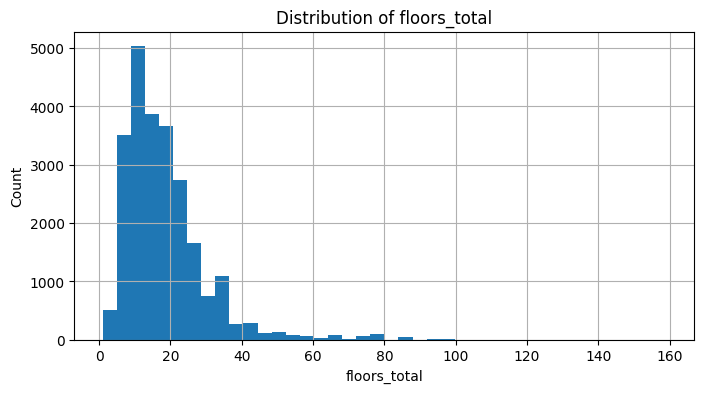

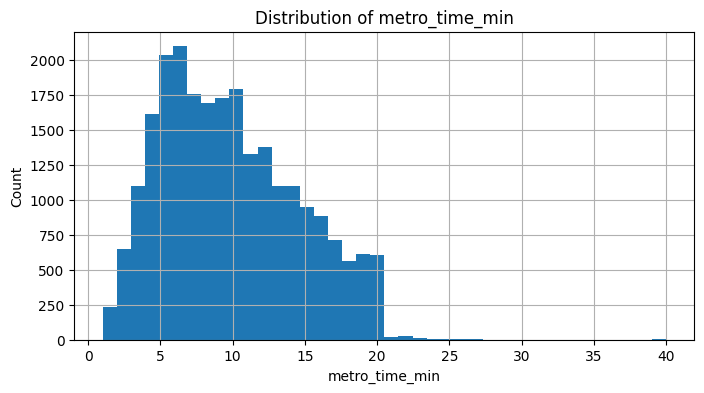

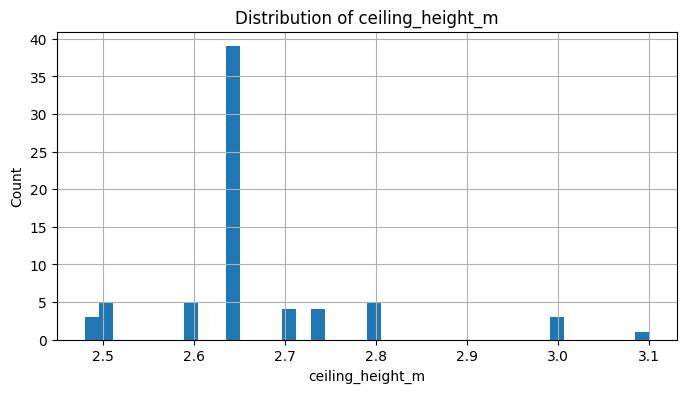

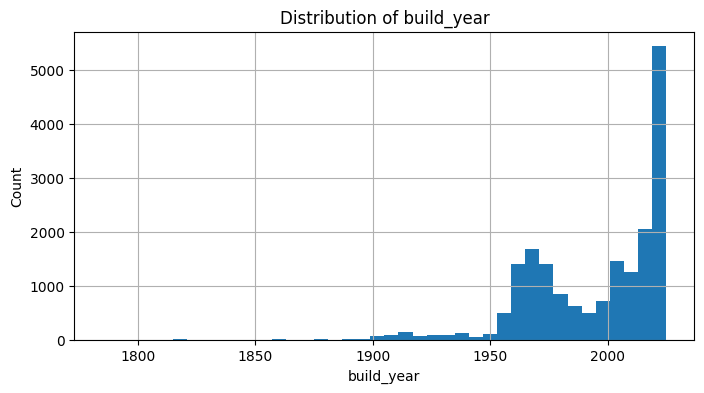

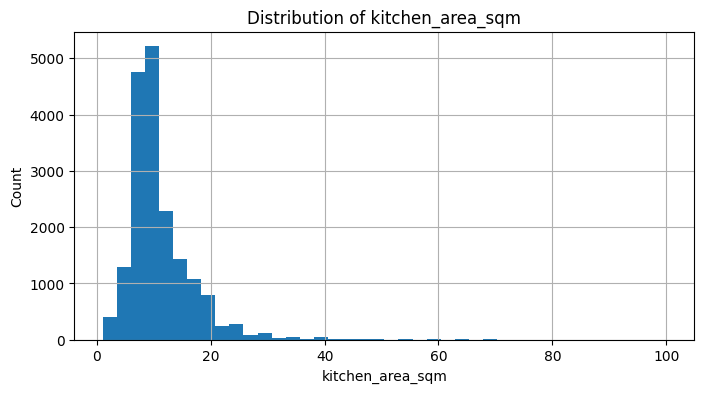

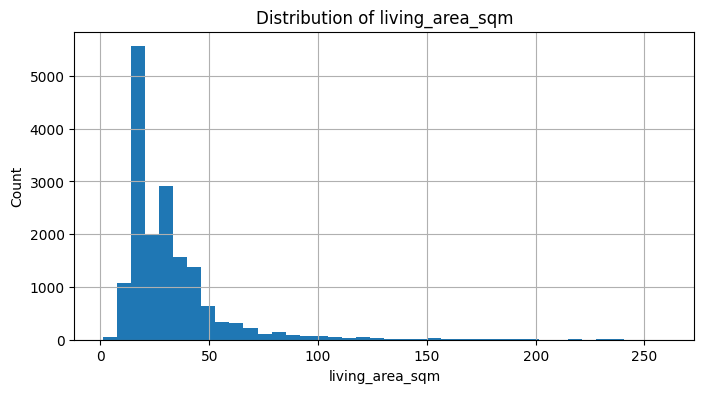

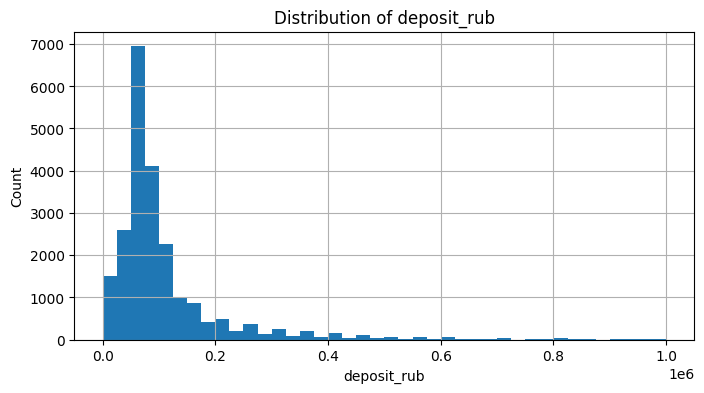

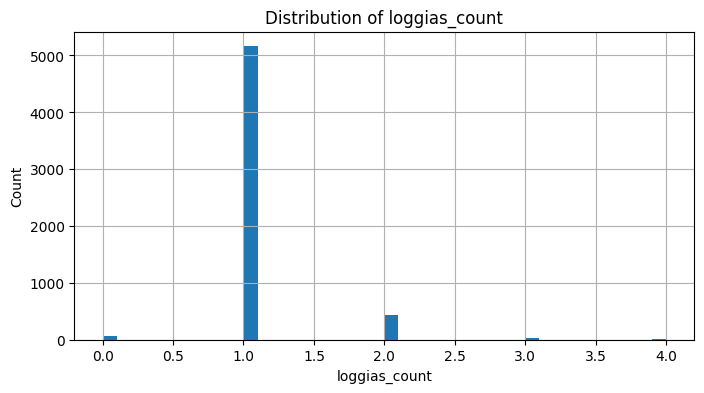

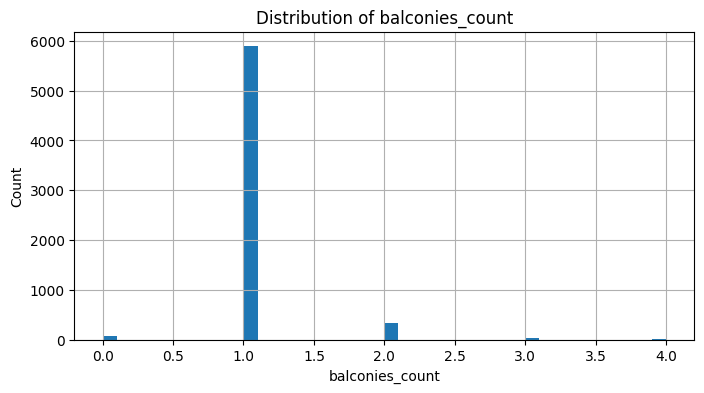

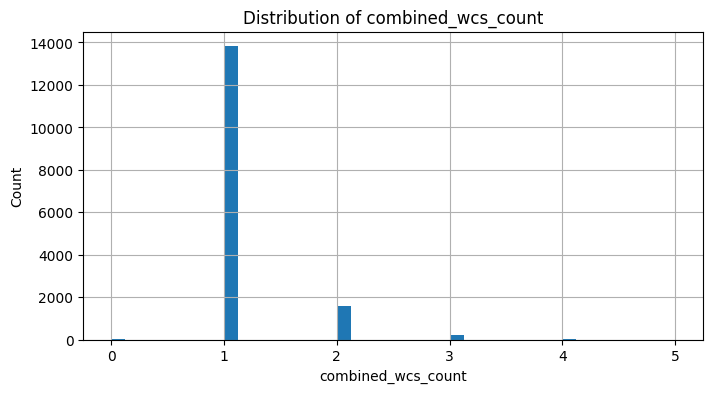

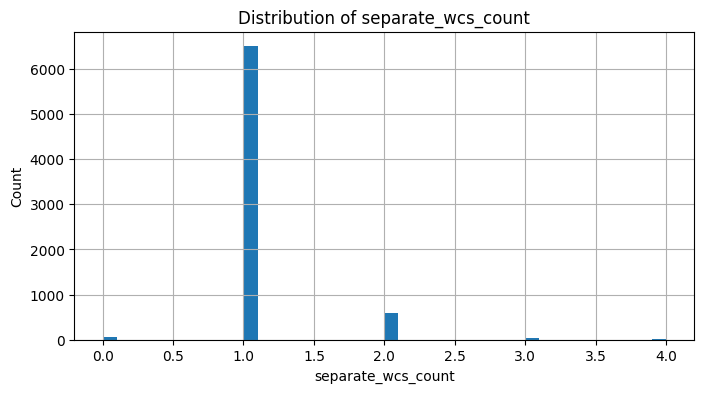

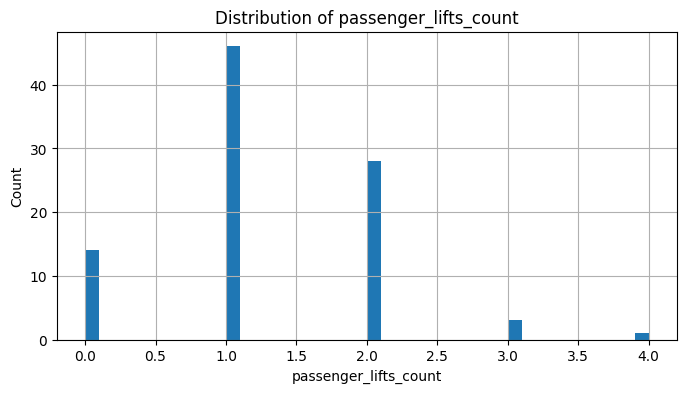

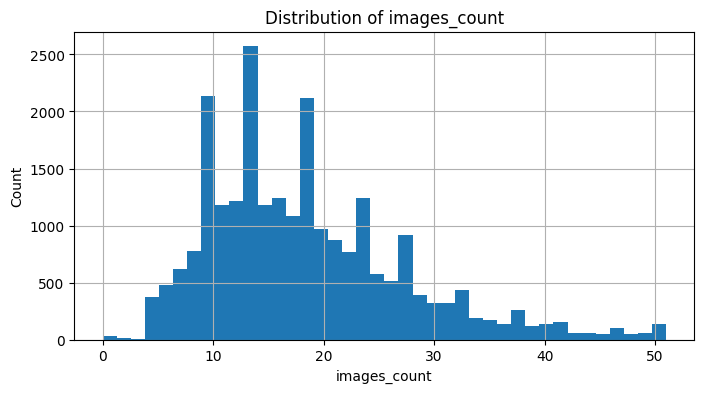

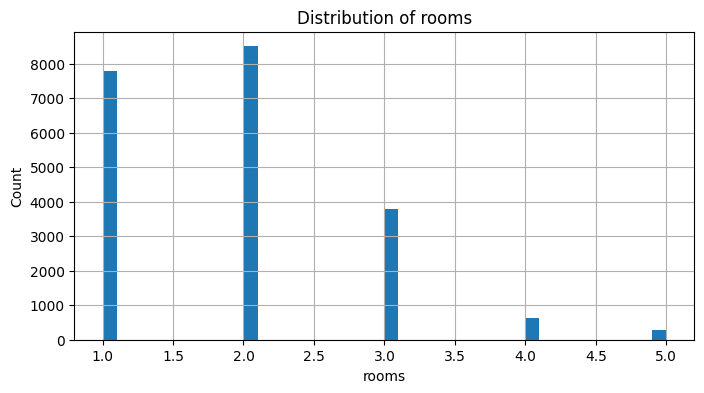

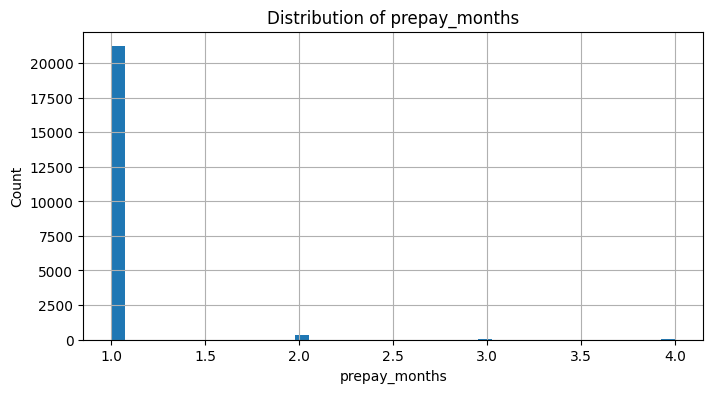

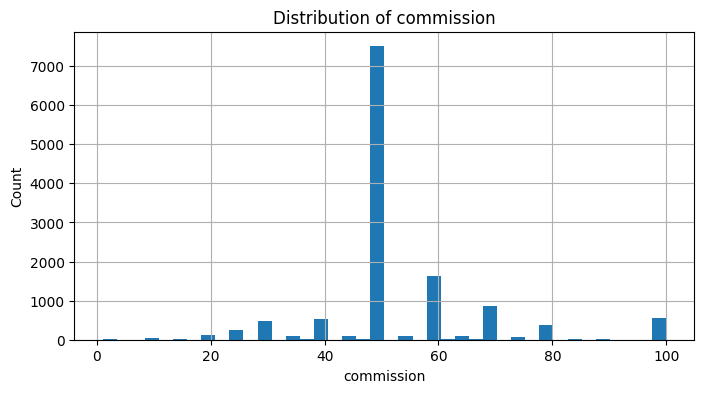

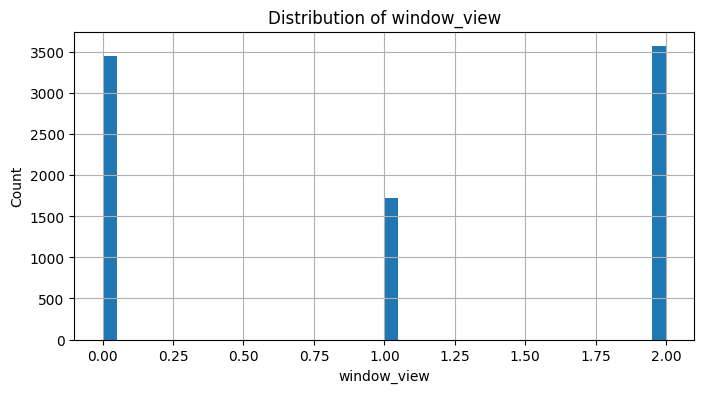

In [ ]:
for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    df[col].hist(bins=40)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

Что можно сразу сказать:
- графики по цене и площади нечитаемые, так как там есть очень большое выбросы, по типу 70 млн рублей в мес, или огромные прощади -> надо убрать выбросы и посмотреть отдельно.
- распределение этажей очень красивое, прям какое то экспоненциальное.
- большая часть квартир находятся достаточно близко к метро, большая часть квартир от 5 до 15 минут. так же важно сказать что >20 минут почти нет квартир, это говорит скорее о большой урбанизации/доступности метро в Москве))
- высота потолков не имеет большого разброса (что логично), там цифры порядка 2-4 метра.
- Про год постройки дома: большая часть жилого фонда города сравнительно молодая, мы не в Венеции живем. Есть два четких кластера: Хрущевки и Брежневки + современное жилье (после нулевых), последних значительно больше. Важно отметить, что мы говорим именно про рынок аренды, а покупки (там старого фонда может быть сильно больше). Но факт в том, что арендные квартиры в подавляющем случае в современных домах. Возможно это те самые инвест квартиры после льготной ипотеки.
- Площадь кухни и living space это почти тоже самое, они скорее всего очень скоррелированны, можно убрать один из них как будто бы.
- кол-во балконов и лоджий это вообще однои тоже, но разное только кол-во
- с туалетами тоже не очень интересно, да и с лифтами
- большинство квартир на сдачу имеют 1-2 комнаты
- абсолютное подавляющее кол-во объявлений требуют предоплату 1 месяца -> вообще признак не очень интересный для задачи определния стоимости квартиры.
- комиссия так же не полезна для определения цены квартиры, у большей части квартир коммисия 50%.
- window_view это уже закодированные наш признак, можно посмотреть выше, в общем большинсва квартир имеют вид во двор или во двор + на цлицу.


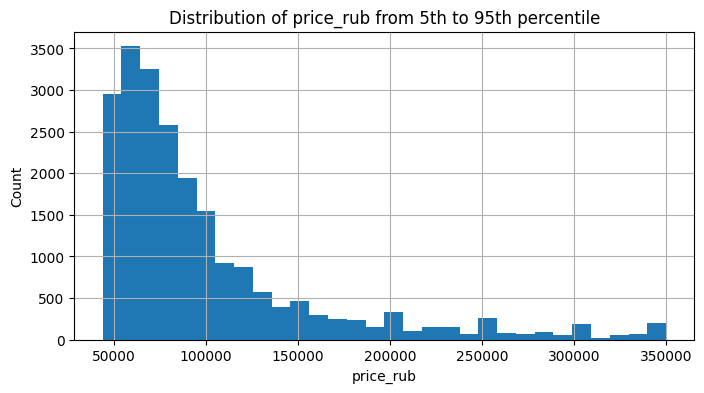

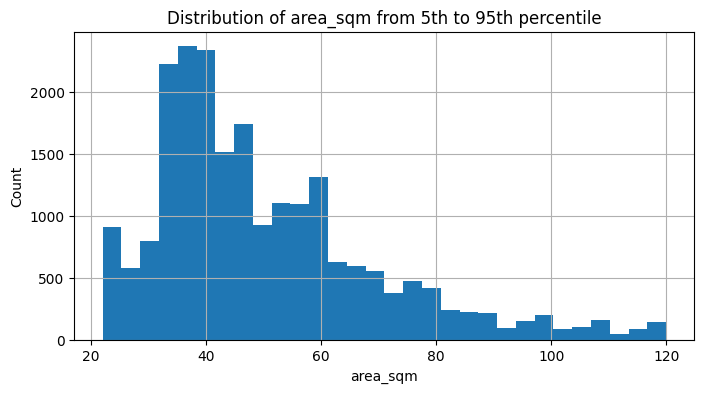

In [ ]:
# давайте посмотрим распределение цены квартир и area убрав выбросы

cols = ["price_rub", "area_sqm"]

for col in cols:
    q_low = df[col].quantile(0.05)
    q_high = df[col].quantile(0.95)

    data = df[col].dropna()
    data = data[(data >= q_low) & (data <= q_high)]

    plt.figure(figsize=(8, 4))
    plt.hist(data, bins=30)
    plt.title(f"Distribution of {col} from 5th to 95th percentile")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.grid()
    plt.show()

Здесь интересная картина, цена это почти экспоненциальное распределение, кажется примерно положина квартир в Москве стоит менее 120 тыс рублей.
При этом от этого размеры квартиры не растут так же))
Оно и понятно, квартира у Кремля 50м2 и 50м2 в Капотне это очень разные вещи, очень разные цены.

Так же интересно что очень много однушек/студий в аренду. Квартир более 60-80 м2 уже не так много, наверное большую часть аренды соствляют более молодые люди, у которых еще нет детей, а значит им и не нужны большие квартиры.

PS Вот и как повышать демографию в таких условиях? в своей стиудии на 25 м2))

### Давайте теперь посмотрим на булевые переменные

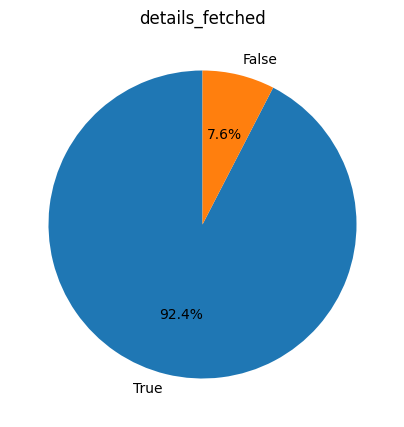

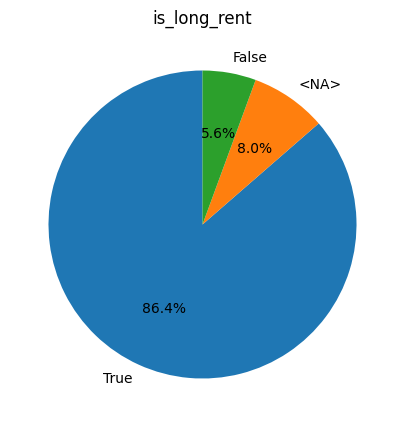

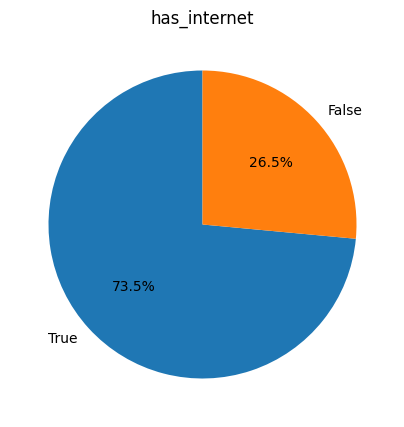

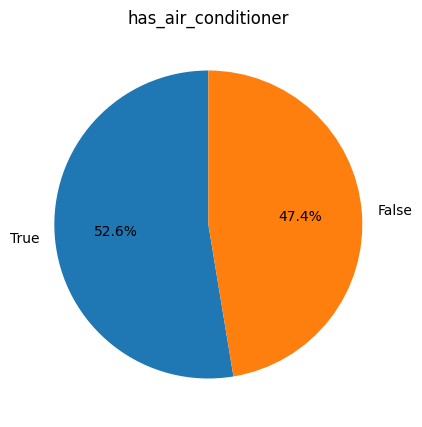

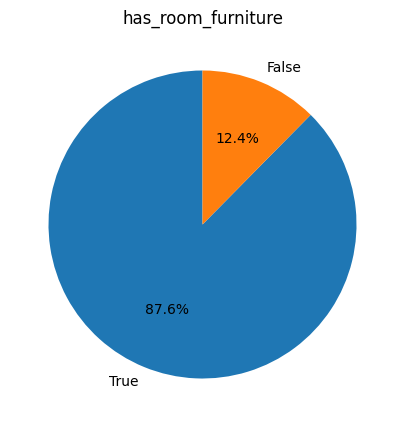

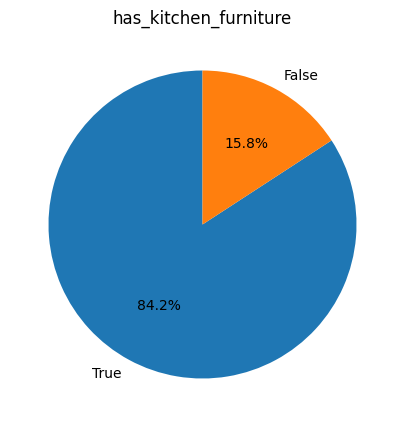

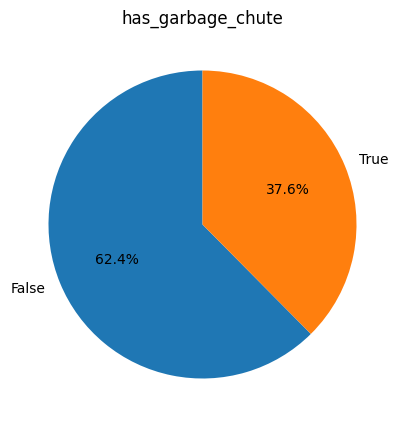

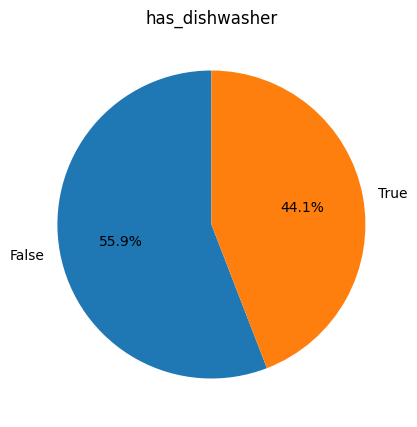

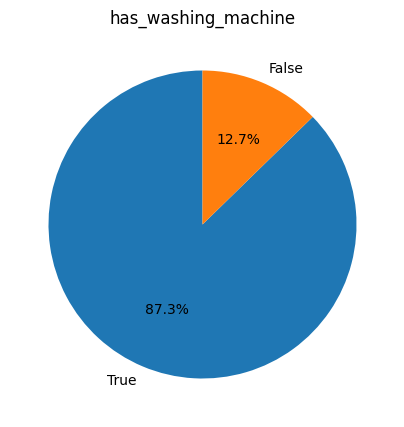

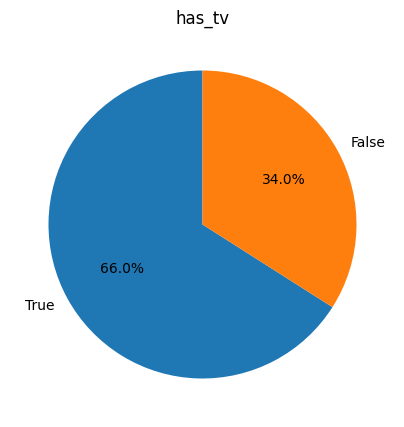

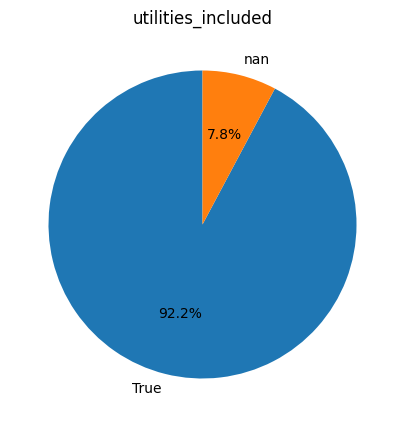

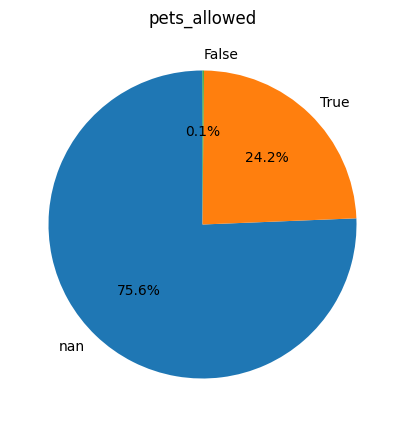

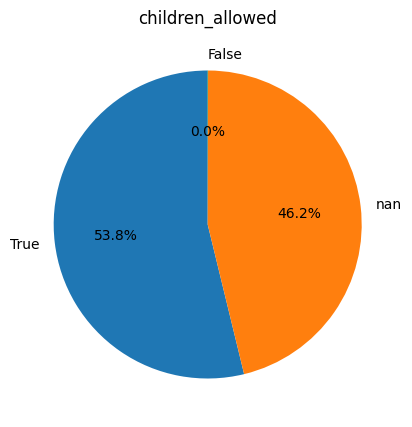

In [ ]:
for col in bool_cols:
    counts = df[col].value_counts(dropna=False)

    plt.figure(figsize=(5, 5))
    plt.pie(
        counts,
        labels=counts.index.astype(str),
        autopct="%1.1f%%",
        startangle=90
    )
    plt.title(col)
    plt.show()

Здесь не так уже и много полезной информации, просто скажем, что например в большинстве квартир есть washing machine, но далеко не везде есть dishwasher.

Так же скажем, что во многих категориях очень много nan значений. Это надо будет решить дальше.

### Давайте посмотрим на категориальные признаки

In [ ]:
for col in categorical_cols:
    print(col, ":", df[col].nunique(dropna=True))

district : 163
metro : 325
author_type : 1
residential_complex : 824
repair_type : 4
house_material : 6
parking_type : 2


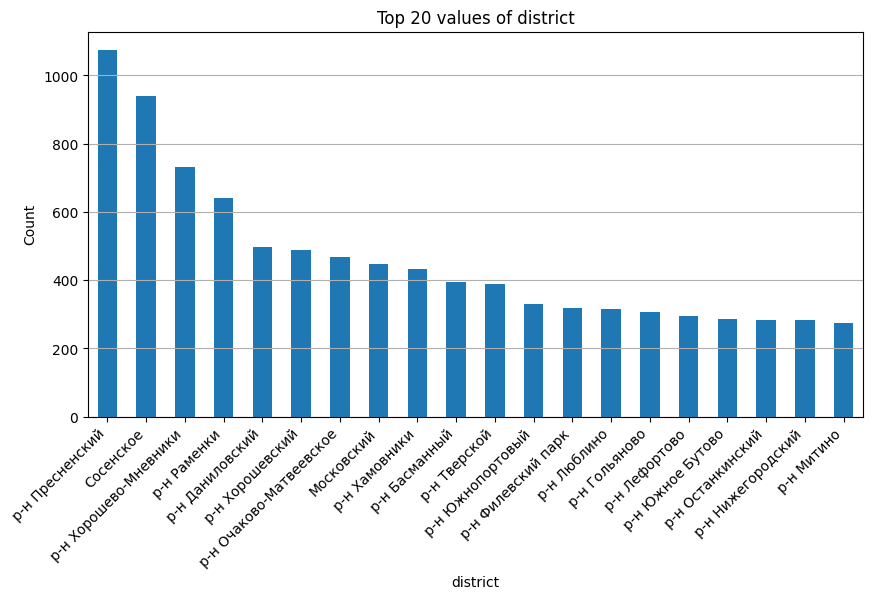

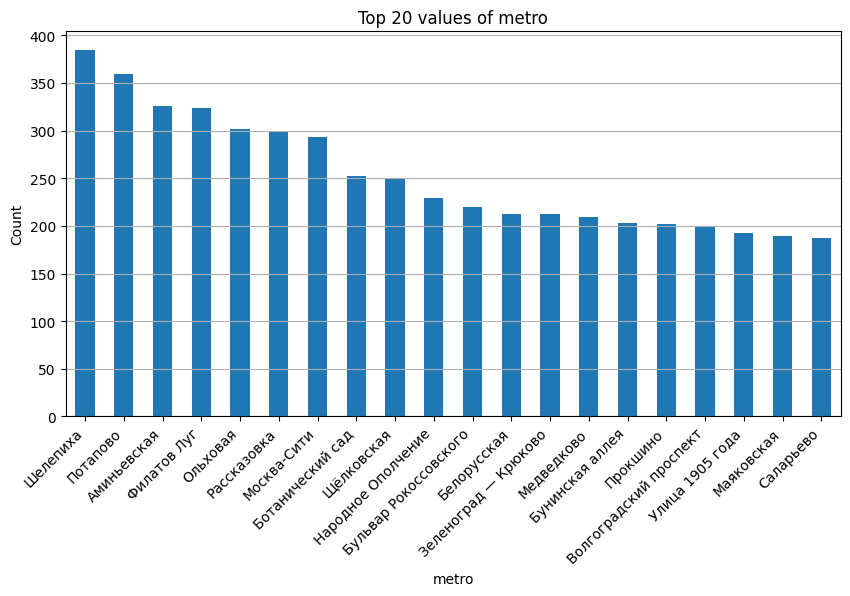

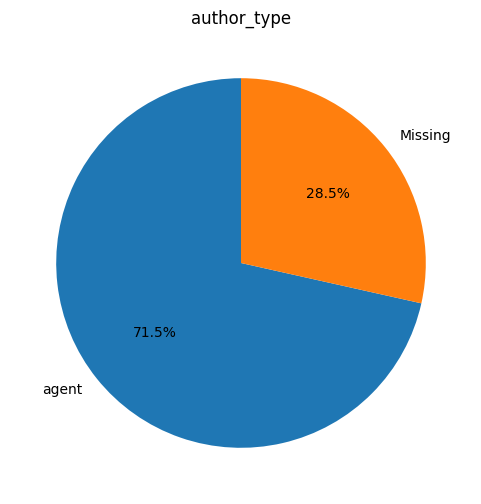

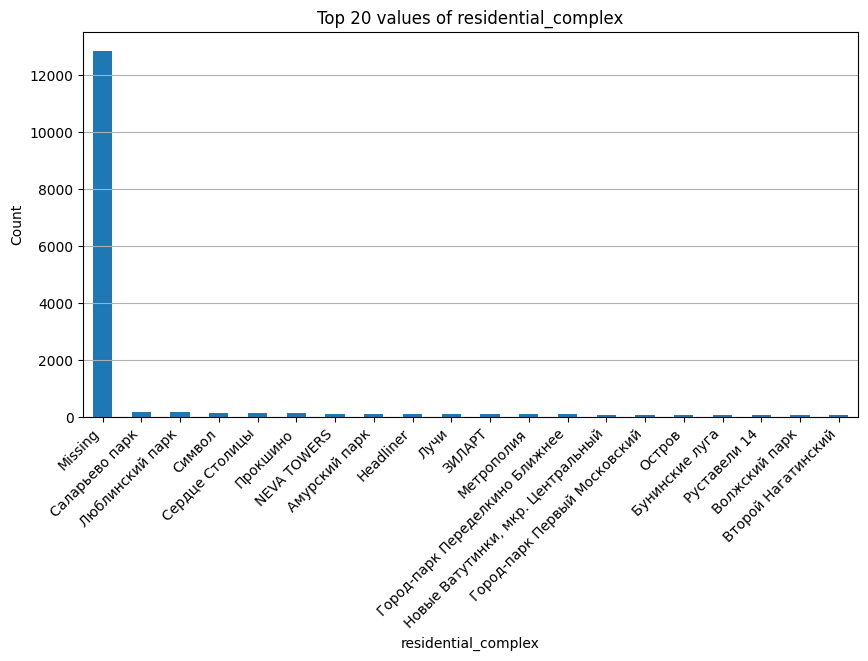

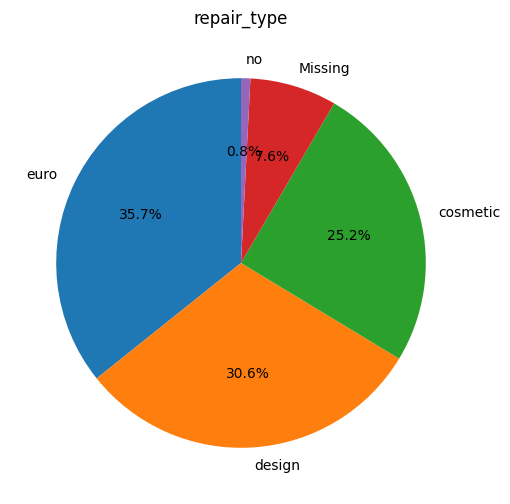

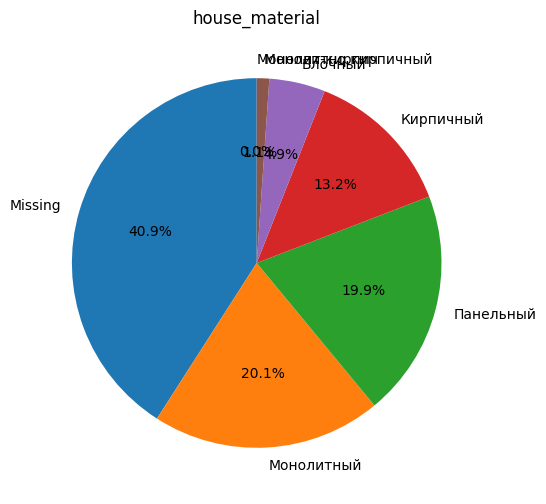

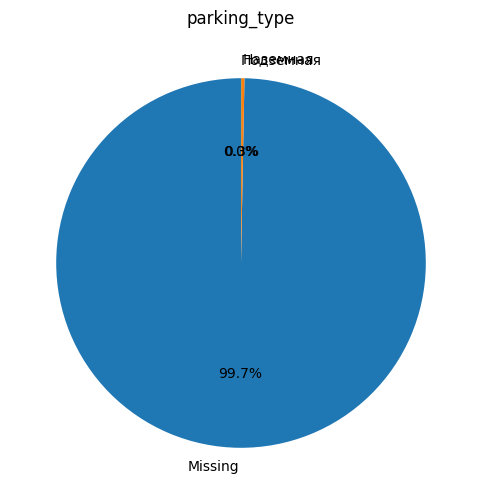

In [ ]:
for col in categorical_cols:
    counts = df[col].fillna("Missing").value_counts()

    # для тех кого меньше 10 сделаем pie chart
    if counts.shape[0] <= 10:
        plt.figure(figsize=(6, 6))
        plt.pie(
            counts,
            labels=counts.index.astype(str),
            autopct="%1.1f%%",
            startangle=90
        )
        plt.title(col)
        plt.show()
    # остальные топ 20 столбчатую диаграмму
    else:
        plt.figure(figsize=(10, 5))
        counts.head(20).plot(kind="bar")
        plt.title(f"Top 20 values of {col}")
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.xticks(rotation=45, ha="right")
        plt.grid(axis="y")
        plt.show()

Выводы:
- много где нет значений (никто не ставит просто) например про парковку. Большинство квартир не имеют ЖК (но вывели, вот посмотрите, где люди снимают квартиры).
- author_type это или агент/или nan. наверное просто стоит убрать этот признак, но про это как раз ниже))

### Давайте теперь посмотрим на пропуски значений
Где они есть, и как заполнять будем.

Давайте разделим на два этот этап:
1. Удалить/обработать по кол-ву missing
2. Удалить/обработаь по смыслу

Сначала первое:

In [ ]:
missing_share = df.isna().mean().sort_values(ascending=False)
missing_share

,0
heating_type,1.000000
ceiling_height_m,0.997132
parking_type,0.997007
passenger_lifts_count,0.996175
loggias_count,0.763168
pets_allowed,0.756392
balconies_count,0.737560
separate_wcs_count,0.701517
window_view,0.636791
residential_complex,0.534691


Видно что есть признаки в которых пропуски составляют более 50% (где то вообще 100), такие признаки по полному праву откинем, так как обрабатывать их будет не очень коррекно (там все равно нет супер важных, так что не переживаем).

In [ ]:
cols_to_drop = missing_share[missing_share > 0.5].index.tolist()
df.drop(columns=cols_to_drop, inplace=True)

Признак `commission` отбросим так как он не будет нести информации полезной для определения цены, даже если мы его заполним средним или чамым частым то это все равно не важно.

`children_allowed` выкинем так как там есть только два значения nan и true, тое есть это признак который всегда будет true (при любом заполнении).

кажется что `house_material` тоже не очень то важен для цены, тоже кик.
Признаки `combined_wcs_count`, `living_area_sqm`, `kitchen_area_sqm` кажется можно апроксимировать через просто площадь, так что тоже выкидываем.

`author_type` тоже выкидываем, так как он имеет только одну категорию, мы не сможем его заполнить.

In [ ]:
df.drop(columns=["commission", "children_allowed", "house_material", "combined_wcs_count", "living_area_sqm", "kitchen_area_sqm", "author_type"], inplace=True)



Там где пропусков слишком мало, мы просто удалим эти объекты из выборки (признаки `metro` и `metro_time_min`)

In [ ]:
df.dropna(subset=['metro', 'metro_time_min'], inplace=True)

#### Далее давайте удалим признаки по смыслу

Удалим `prepay_months` так как большая часть из них это 1 месяц, и оно не несет никакой ценности для определения цены.

Удалим столбцы `utilities_included` и `details_fetched` потому что они показывают есть лти какие то доп флаги, это было на этапе парсинга, и информация об этом столбце уже есть в других столбцах с доп информацией (есть ли телевизор? можно ли детей? и тд)


И важно!!! удаляем столбце с депозитом `deposit_rub`, так как это прокси метрика для цены, а значит это утечка данных!

In [ ]:
df.drop(columns=["prepay_months", "utilities_included", "deposit_rub", "details_fetched"], inplace=True)

Так как `repair_type` является таргетом к нашей второй части задания, то я просто уберу сэмплы с nan, да их целых 7%, но все же.

In [ ]:
df.dropna(subset=['repair_type'], inplace=True)

In [ ]:
df.isna().mean().sort_values(ascending=False)

,0
build_year,0.160132
rooms,0.128502
is_long_rent,0.004377
price_rub,0.000000
floor,0.000000
area_sqm,0.000000
floors_total,0.000000
district,0.000000
metro_time_min,0.000000
metro,0.000000


Такс, ну теперь давайте уже и `is_long_rent` семплы удалим, потому что их осталось только 0,4% nan.

In [ ]:
df.dropna(subset=['is_long_rent'], inplace=True)

Теперь нам необходимо обработать пропуски всего в двух признаках: `build_year` и `rooms`.

На самом деле для простоты и чтобы избежать сложностей с нормализаций, утечкой данных и тд при "умном" заполнении с помощью ml моделей, мы воспользуемся простыми стратегиями.

In [ ]:
from sklearn.impute import SimpleImputer

print(df[["build_year", "rooms"]].isna().sum())

df["build_year"] = SimpleImputer(strategy="median").fit_transform(df[["build_year"]]).ravel()
df["rooms"] = SimpleImputer(strategy="most_frequent").fit_transform(df[["rooms"]]).ravel()

build_year    3535
rooms         2848
dtype: int64


Так же важно, что по смыслу столбцы должны быть целыми

In [ ]:
df["build_year"] = df["build_year"].round().astype(int)
df["rooms"] = df["rooms"].round().astype(int)

In [ ]:
df.isna().sum().sum()

np.int64(0)

Ура! пропусков уже нет! Теперь можно перейти к кодированию категориальных переменных и фиче инженирингу!

### Кодирование признаков

In [ ]:
df.sample(5)

,price_rub,rooms,area_sqm,floor,floors_total,district,metro,metro_time_min,repair_type,build_year,images_count,is_long_rent,has_internet,has_air_conditioner,has_room_furniture,has_kitchen_furniture,has_garbage_chute,has_dishwasher,has_washing_machine,has_tv
1561,50000,1,40.0,3,17,Московский,Рассказовка,8.0,euro,2012,12,True,True,False,True,True,False,False,True,True
20448,165000,4,116.0,21,23,р-н Теплый Стан,Тёплый Стан,9.0,euro,2006,36,True,True,True,True,True,True,True,True,True
18869,220000,3,73.0,11,20,р-н Филевский парк,Фили,9.0,design,2021,13,True,True,True,True,True,False,True,True,True
5914,75000,1,36.0,7,45,р-н Западное Дегунино,Селигерская,11.0,euro,2021,17,True,True,False,True,True,False,False,True,False
2929,55000,1,38.0,10,12,р-н Северное Медведково,Медведково,15.0,cosmetic,2004,9,True,False,True,True,False,True,False,True,True


In [ ]:
df.shape

(22066, 20)

In [ ]:
df = pd.get_dummies(df, columns=["district", "metro"], prefix=["district", "metro"], dtype=bool)
df.sample(5)

,price_rub,rooms,area_sqm,floor,floors_total,metro_time_min,repair_type,build_year,images_count,is_long_rent,has_internet,has_air_conditioner,has_room_furniture,has_kitchen_furniture,has_garbage_chute,has_dishwasher,has_washing_machine,has_tv,district_Внуковское,district_Воскресенское,district_Десёновское,district_ЗАО,district_Киевский,district_Кокошкино,district_Марушкинское,district_Московский,district_Мосрентген,district_Новофёдоровское,district_Первомайское,district_Рязановское,district_Сосенское,district_Троицк,district_Филимонковское,district_Щаповское,district_Щербинка,district_мкр. 1-й,district_мкр. 10-й,district_мкр. 11-й,district_мкр. 12-й,district_мкр. 14-й,district_мкр. 15-й,district_мкр. 16-й,district_мкр. 17-й,district_мкр. 18-й,district_мкр. 19-й,district_мкр. 2-й,district_мкр. 20-й,district_мкр. 23-й,district_мкр. 3-й,district_мкр. 4-й,district_мкр. 5-й,district_мкр. 6-й,district_мкр. 8-й,district_мкр. 9-й,district_р-н Академический,district_р-н Алексеевский,district_р-н Алтуфьевский,district_р-н Арбат,district_р-н Аэропорт,district_р-н Бабушкинский,district_р-н Басманный,district_р-н Беговой,district_р-н Бескудниковский,district_р-н Бибирево,district_р-н Бирюлево Восточное,district_р-н Бирюлево Западное,district_р-н Богородское,district_р-н Братеево,district_р-н Бутырский,district_р-н Вешняки,district_р-н Внуково,district_р-н Войковский,district_р-н Восточное Дегунино,district_р-н Восточное Измайлово,district_р-н Восточный,district_р-н Выхино-Жулебино,district_р-н Гагаринский,district_р-н Головинский,district_р-н Гольяново,district_р-н Даниловский,district_р-н Дмитровский,district_р-н Донской,district_р-н Дорогомилово,district_р-н Замоскворечье,district_р-н Западное Дегунино,district_р-н Зюзино,district_р-н Зябликово,district_р-н Ивановское,district_р-н Измайлово,district_р-н Капотня,district_р-н Коньково,district_р-н Коптево,district_р-н Косино-Ухтомский,district_р-н Котловка,district_р-н Красносельский,district_р-н Крылатское,district_р-н Крюково,district_р-н Кузьминки,district_р-н Кунцево,district_р-н Куркино,district_р-н Левобережный,district_р-н Лефортово,district_р-н Лианозово,district_р-н Ломоносовский,district_р-н Лосиноостровский,district_р-н Люблино,district_р-н Марфино,district_р-н Марьина роща,district_р-н Марьино,district_р-н Метрогородок,district_р-н Мещанский,district_р-н Митино,district_р-н Можайский,district_р-н Молжаниновский,district_р-н Москворечье-Сабурово,district_р-н Нагатино-Садовники,district_р-н Нагатинский затон,district_р-н Нагорный,district_р-н Некрасовка,district_р-н Нижегородский,district_р-н Новая Москва,district_р-н Ново-Переделкино,district_р-н Новогиреево,district_р-н Новокосино,district_р-н Обручевский,district_р-н Орехово-Борисово Северное,district_р-н Орехово-Борисово Южное,district_р-н Останкинский,district_р-н Отрадное,district_р-н Очаково-Матвеевское,district_р-н Перово,district_р-н Печатники,district_р-н Покровское-Стрешнево,district_р-н Преображенское,district_р-н Пресненский,district_р-н Проспект Вернадского,district_р-н Раменки,district_р-н Ростокино,district_р-н Рязанский,district_р-н Савеловский,district_р-н Савёлки,district_р-н Свиблово,district_р-н Северное Бутово,district_р-н Северное Измайлово,district_р-н Северное Медведково,district_р-н Северное Тушино,district_р-н Северный,district_р-н Сокол,district_р-н Соколиная гора,district_р-н Сокольники,district_р-н Солнцево,district_р-н Строгино,district_р-н Таганский,district_р-н Тверской,district_р-н Текстильщики,district_р-н Теплый Стан,district_р-н Тимирязевский,district_р-н Тропарево-Никулино,district_р-н Филевский парк,district_р-н Фили-Давыдково,district_р-н Хамовники,district_р-н Ховрино,district_р-н Хорошево-Мневники,district_р-н Хорошевский,district_р-н Царицыно,district_р-н Черемушки,district_р-н Чертаново Северное,district_р-н Чертаново Центральное,district_р-н Чертаново Южное,district_р-н Щукино,district_р-н Южное Бутово,district_р-н Южное Медведково,district_р-н Южное Тушино,district_р-н Южнопортовый,di

In [ ]:
df.shape

(22066, 501)

In [ ]:
df['repair_type'].value_counts()

,count
repair_type,
euro,8569
design,7340
cosmetic,5965
no,192


In [ ]:
repair_type_mapping = {
    "no": 0,
    "cosmetic": 1,
    "euro": 2,
    "design": 3
}

df["repair_type"] = df["repair_type"].map(repair_type_mapping)

### Теперь давайте сделаем новые признаки

Для начала давайте сделаем признаки, на основе данных об этажности.

1. `floor_ratio` как floor / floors_total
2. `is_first_floor`
3. `is_last_floor`
4. `is_skyscraper`
5. `is_mid_rise_building` если floors_total от 6 до 16

In [ ]:
df["floor_ratio"] = df["floor"] / df["floors_total"]
df["is_first_floor"] = df["floor"] == 1
df["is_last_floor"] = df["floor"] == df["floors_total"]
df["is_skyscraper"] = df["floors_total"] >= 30

In [ ]:
df["is_high_floor"] = df["floor_ratio"] >= 0.7

In [ ]:
df["is_mid_rise_building"] = df["floors_total"].between(6, 16)

df.drop(columns=["floor", "floors_total"], inplace=True)

Еще давайте сделаем признак `has_images` если есть хоть одно фото, а затем удалим кол-во фото.

In [ ]:
df["has_images"] = df["images_count"] > 0

df.drop(columns=["images_count"], inplace=True)

In [ ]:
# Теперь итоговый размер датасета

df.shape

(22066, 505)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 22066 entries, 0 to 24054
Columns: 505 entries, price_rub to is_mid_rise_building
dtypes: bool(497), boolean(1), float64(3), int64(4)
memory usage: 11.8 MB


In [ ]:
X = df.drop(columns=["price_rub"])
y = df["price_rub"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2026)

In [ ]:
from sklearn.preprocessing import StandardScaler

bool_mask = X_train.dtypes.isin(["bool", "boolean"])
scale_cols = X_train.columns[~bool_mask]
bool_cols = X_train.columns[bool_mask]

scaler = StandardScaler()

X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test[scale_cols] = scaler.transform(X_test[scale_cols])

X_train[bool_cols] = X_train[bool_cols].astype(int)
X_test[bool_cols] = X_test[bool_cols].astype(int)


In [ ]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (17652, 504)
X_test: (4414, 504)
y_train: (17652,)
y_test: (4414,)


In [ ]:
X_train.to_csv("X_train.csv", index=True)
X_test.to_csv("X_test.csv", index=True)

y_train.to_frame(name="price_rub").to_csv("y_train.csv", index=True)
y_test.to_frame(name="price_rub").to_csv("y_test.csv", index=True)